# Validate gene signature in external study


In [1]:
quiet_library <- function(...) {
  suppressPackageStartupMessages(library(...))
}
quiet_library("tidyverse")
quiet_library("data.table")
quiet_library("ggplot2")
quiet_library("dplyr")
quiet_library("ggpubr")
quiet_library("broom")

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘purrr’ was built under R version 4.4.2”
Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
Warning message:
“package ‘data.table’ was built under R version 4.4.3”


In [2]:
# define the color palette to be used
npg_color <- c(
  "#E64B35FF", "#4DBBD5FF", "#00A087FF", "#3C5488FF", "#F39B7FFF",
  "#8491B4FF", "#91D1C2FF", "#DC0000FF", "#7E6148FF", "#B09C85FF"
)
npg_color_ext <- colorRampPalette(npg_color)(15)
nejm_color <- c("#BC3C29FF", "#0072B5FF", "#E18727FF", "#20854EFF", "#7876B1FF", "#6F99ADFF", "#FFDC91FF", "#EE4C97FF")
jama_color <- c("#374E55FF", "#DF8F44FF", "#00A1D5FF", "#B24745FF", "#79AF97FF", "#6A6599FF", "#80796BFF")
jco_color <- c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF", "#7AA6DCFF", "#003C67FF", "#8F7700FF")
cluster_colors <- c(
  "#DC050C", "#FB8072", "#1965B0", "#7BAFDE", "#882E72", "#B17BA6", "#FF7F00", "#FDB462", "#E7298A",
  "#E78AC3", "#33A02C", "#B2DF8A", "#55A1B1", "#8DD3C7", "#A6761D", "#E6AB02", "#7570B3", "#BEAED4", "#666666", "#999999",
  "#aa8282", "#d4b7b7", "#8600bf", "#ba5ce3", "#808000", "#aeae5c", "#1e90ff", "#00bfff", "#56ff0d", "#ffff00"
)
cluster_colors_ext <- colorRampPalette(cluster_colors)(36)

tnfi_colors <- c("grey80", "#F59F00", "#840032", "grey80")
options(repr.plot.width = 6, repr.plot.height = 6)

In [3]:
# define working path
data_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/GSE129705"
meta_path <- "/home/workspace/github/ra-longitudinal/metadata"
fig_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/figures"
output_path <- "/home/workspace/private/ra-cohort-ide/ALTRA_revision/TNFi/GSE129705/results"
if (!dir.exists(fig_path)) (dir.create(fig_path, recursive = TRUE))
proj_name <- "ALTRA_AIM3_scRNA_tnfi_validation_"

In [4]:
run_mcnemar_test <- function(x) {
  cont_counts <- x %>%
    pivot_wider(
      id_cols = aim3_direction,
      names_from = tnfi_direction, values_from = n
    )
  # print(cont_counts)
  test_res <- rstatix::mcnemar_test(cont_counts %>% select(-aim3_direction)) %>% as_tibble()
  return(test_res)
}

## load data


In [5]:
# load tnfi degs in related to aim3
tnfi_aim3_degs_comparison_sig <- read_csv(file.path(output_path, "ALTRA_AIM3_scRNA_tnfi_validation_tnfi_responder_AIM3_degs.csv")) %>%
  mutate(direction = factor(direction))

Rows: 1415 Columns: 21
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (8): gene, cell_type, effect, term, sig, aim3_direction, tnfi_direction...
dbl (12): baseMean, log2FoldChange, lfcSE, stat, pvalue, q_values_tnfi, esti...
lgl  (1): group

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [8]:
# make the count table
tnfi_aim3_deg_counts <- tnfi_aim3_degs_comparison_sig %>%
  group_by(cell_type, aim3_direction, tnfi_direction) %>%
  tally() %>%
  mutate(treatment = "TNFi") %>%
  dplyr::rename("treatment_direction" = "tnfi_direction")
tnfi_aim3_deg_counts %>% head()

cell_type,aim3_direction,treatment_direction,n,treatment
<chr>,<chr>,<chr>,<int>,<chr>
CD27+ effector B cell,aim3_down,tnfi_up,1,TNFi
CM CD4 T cell,aim3_down,tnfi_down,130,TNFi
CM CD4 T cell,aim3_down,tnfi_up,219,TNFi
CM CD4 T cell,aim3_up,tnfi_down,124,TNFi
CM CD4 T cell,aim3_up,tnfi_up,149,TNFi
CM CD8 T cell,aim3_down,tnfi_down,1,TNFi


In [10]:
# load ab treatment degs
abt_aim3_degs <- read_csv("/home/workspace/private/ra-cohort-ide/ALTRA_manuscript/treatment_validation/ALTRA_AIM3_scRNA_validation_ABT_responder_AIM3_degs.csv",
  show_col_types = FALSE
)
abt_aim3_deg_counts <- abt_aim3_degs %>%
  group_by(cell_type, aim3_direction, abt_direction) %>%
  tally() %>%
  mutate(treatment = "ABT") %>%
  rename("treatment_direction" = "abt_direction")
abt_aim3_deg_counts %>% head()

cell_type,aim3_direction,treatment_direction,n,treatment
<chr>,<chr>,<chr>,<int>,<chr>
CM CD4 T cell,aim3_down,abt_down,8,ABT
CM CD4 T cell,aim3_down,abt_up,165,ABT
CM CD4 T cell,aim3_up,abt_down,37,ABT
CM CD4 T cell,aim3_up,abt_up,23,ABT
CM CD8 T cell,aim3_down,abt_down,1,ABT
Core naive B cell,aim3_down,abt_up,3,ABT


### calculate and plot the odds ratio


In [11]:
quiet_library("epitools")

In [12]:
abt_tnfi_aim3_deg_counts <- bind_rows(abt_aim3_deg_counts, tnfi_aim3_deg_counts) %>%
  mutate(treatment_direction = paste0("treatment_", str_extract(treatment_direction, "up|down")))
abt_tnfi_aim3_deg_counts %>% head()

cell_type,aim3_direction,treatment_direction,n,treatment
<chr>,<chr>,<chr>,<int>,<chr>
CM CD4 T cell,aim3_down,treatment_down,8,ABT
CM CD4 T cell,aim3_down,treatment_up,165,ABT
CM CD4 T cell,aim3_up,treatment_down,37,ABT
CM CD4 T cell,aim3_up,treatment_up,23,ABT
CM CD8 T cell,aim3_down,treatment_down,1,ABT
Core naive B cell,aim3_down,treatment_up,3,ABT


In [13]:
degs_counts_test <- abt_tnfi_aim3_deg_counts %>%
  ungroup() %>%
  filter(cell_type == "CM CD4 T cell" & treatment == "ABT") %>%
  mutate(
    aim3_direction = factor(aim3_direction, levels = c("aim3_up", "aim3_down")),
    treatment_direction = factor(treatment_direction, levels = c("treatment_up", "treatment_down"))
  ) %>%
  select(-c(cell_type, treatment))
outcome <- "treatment_direction"
exposure <- "aim3_direction"
contingency_table <- degs_counts_test %>%
  pivot_wider(names_from = all_of(outcome), values_from = "n", values_fill = 0) %>%
  column_to_rownames(var = exposure) %>%
  select(treatment_up, treatment_down) %>%
  as.matrix()
contingency_table
# Compute odds ratio using epitools
or_result <- oddsratio(contingency_table)
# Extract relevant results
or_summary <- data.frame(
  Odds_Ratio = or_result$measure[2, 1],
  Lower_CI = or_result$measure[2, 2],
  Upper_CI = or_result$measure[2, 3],
  p_value = or_result$p.value[2, 1]
)
or_summary

,treatment_up,treatment_down
aim3_down,165,8
aim3_up,23,37


Odds_Ratio,Lower_CI,Upper_CI,p_value
<dbl>,<dbl>,<dbl>,<dbl>
31.90157,13.80269,82.71166,0


In [14]:
# Function to compute odds ratio from a summary tibble
compute_or_from_summary <- function(deg_counts, celltype_sel, treatment_sel,
                                    exposure = "aim3_direction", outcome = "treatment_direction", count = "n") {
  # Check if exposure, outcome, and count columns exist
  if (!all(c(exposure, outcome, count) %in% names(deg_counts))) {
    stop("Error: Specified columns not found in the dataset.")
  }
  # filter deg counts
  # celltype_sel = unique(deg_counts%>% pull(cell_type))
  # treatment_sel = unique(deg_counts%>% pull(treatment))
  deg_counts_fl <- deg_counts %>%
    ungroup() %>%
    mutate(
      aim3_direction = factor(aim3_direction, levels = c("aim3_up", "aim3_down")),
      treatment_direction = factor(treatment_direction, levels = c("treatment_up", "treatment_down"))
    )

  # Convert to wide-format contingency table
  outcome_levels <- deg_counts_fl %>%
    pull(outcome) %>%
    levels()
  contingency_table <- deg_counts_fl %>%
    pivot_wider(names_from = !!sym(outcome), values_from = !!sym(count), values_fill = 0) %>%
    column_to_rownames(var = exposure) %>%
    select(all_of(outcome_levels)) %>%
    as.matrix()
  print(paste(treatment_sel, celltype_sel))
  print(contingency_table)
  # Ensure the table is 2x2
  if (!all(dim(contingency_table) == c(2, 2))) {
    stop("Error: Contingency table must be 2x2.")
  }

  # Compute odds ratio using epitools
  or_result <- oddsratio(contingency_table, method = "wald")

  # Extract relevant results
  or_summary <- data.frame(
    Odds_Ratio = or_result$measure[2, 1],
    Lower_CI = or_result$measure[2, 2],
    Upper_CI = or_result$measure[2, 3],
    p_value = or_result$p.value[2, 1]
  ) %>%
    as_tibble() %>%
    mutate("cell_type" = !!(celltype_sel), "treatment" = !!(treatment_sel))

  return(or_summary)
}

In [16]:
cd4cm_or <- abt_tnfi_aim3_deg_counts %>%
  filter(cell_type == "CM CD4 T cell" & treatment == "ABT") %>%
  compute_or_from_summary(
    celltype_sel = "CM CD4 T cell", treatment_sel = "ABT",
    exposure = "treatment_direction", outcome = "aim3_direction"
  )
cd4na_or <- abt_tnfi_aim3_deg_counts %>%
  filter(cell_type == "Core naive CD4 T cell" & treatment == "ABT") %>%
  compute_or_from_summary(
    celltype_sel = "Core naive CD4 T cell",
    treatment_sel = "ABT", exposure = "treatment_direction", outcome = "aim3_direction"
  )

[1] "ABT CM CD4 T cell"
               aim3_up aim3_down
treatment_down      37         8
treatment_up        23       165
[1] "ABT Core naive CD4 T cell"
               aim3_up aim3_down
treatment_down      40        11
treatment_up        22       164


In [17]:
cd4cm_or
cd4na_or

Odds_Ratio,Lower_CI,Upper_CI,p_value,cell_type,treatment
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
33.17935,13.76295,79.98786,0,CM CD4 T cell,ABT


Odds_Ratio,Lower_CI,Upper_CI,p_value,cell_type,treatment
<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
27.10744,12.15513,60.45293,0,Core naive CD4 T cell,ABT


In [18]:
abt_tnfi_aim3_deg_counts %>%
  filter(cell_type %in% c("CM CD4 T cell", "Core naive CD4 T cell")) %>%
  pivot_wider(
    id_cols = c("treatment", "cell_type", "aim3_direction"),
    names_from = "treatment_direction", values_from = "n", values_fill = 0
  )

treatment,cell_type,aim3_direction,treatment_down,treatment_up
<chr>,<chr>,<chr>,<int>,<int>
ABT,CM CD4 T cell,aim3_down,8,165
ABT,CM CD4 T cell,aim3_up,37,23
ABT,Core naive CD4 T cell,aim3_down,11,164
ABT,Core naive CD4 T cell,aim3_up,40,22
TNFi,CM CD4 T cell,aim3_down,130,219
TNFi,CM CD4 T cell,aim3_up,124,149
TNFi,Core naive CD4 T cell,aim3_down,112,210
TNFi,Core naive CD4 T cell,aim3_up,108,150


In [19]:
# get odds ratio for all cell type
or_results <- abt_tnfi_aim3_deg_counts %>%
  filter(cell_type %in% c("CM CD4 T cell", "Core naive CD4 T cell")) %>%
  group_by(cell_type, treatment) %>%
  group_modify(~ compute_or_from_summary(.x,
    celltype_sel = unique(.x$cell_type), treatment_sel = unique(.x$treatment),
    exposure = "treatment_direction", outcome = "aim3_direction", count = "n"
  )) %>%
  mutate("treament.celltype" = paste(treatment, cell_type, sep = ": "))

Warning message:
“Unknown or uninitialised column: `treatment`.”
Warning message:
“Unknown or uninitialised column: `cell_type`.”


character(0)
               aim3_up aim3_down
treatment_down      37         8
treatment_up        23       165


Warning message:
“Unknown or uninitialised column: `treatment`.”
Warning message:
“Unknown or uninitialised column: `cell_type`.”


character(0)
               aim3_up aim3_down
treatment_down     124       130
treatment_up       149       219


Warning message:
“Unknown or uninitialised column: `treatment`.”
Warning message:
“Unknown or uninitialised column: `cell_type`.”


character(0)
               aim3_up aim3_down
treatment_down      40        11
treatment_up        22       164


Warning message:
“Unknown or uninitialised column: `treatment`.”
Warning message:
“Unknown or uninitialised column: `cell_type`.”


character(0)
               aim3_up aim3_down
treatment_down     108       112
treatment_up       150       210


In [20]:
or_results %>% head()

cell_type,treatment,Odds_Ratio,Lower_CI,Upper_CI,p_value,treament.celltype
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CM CD4 T cell,ABT,33.179348,13.7629531,79.987857,0.00000000,ABT: CM CD4 T cell
CM CD4 T cell,TNFi,1.401962,1.0157347,1.935049,0.04037894,TNFi: CM CD4 T cell
Core naive CD4 T cell,ABT,27.107438,12.1551293,60.452931,0.00000000,ABT: Core naive CD4 T cell
Core naive CD4 T cell,TNFi,1.350000,0.9634894,1.891562,0.08212868,TNFi: Core naive CD4 T cell


## plot Fig 7H

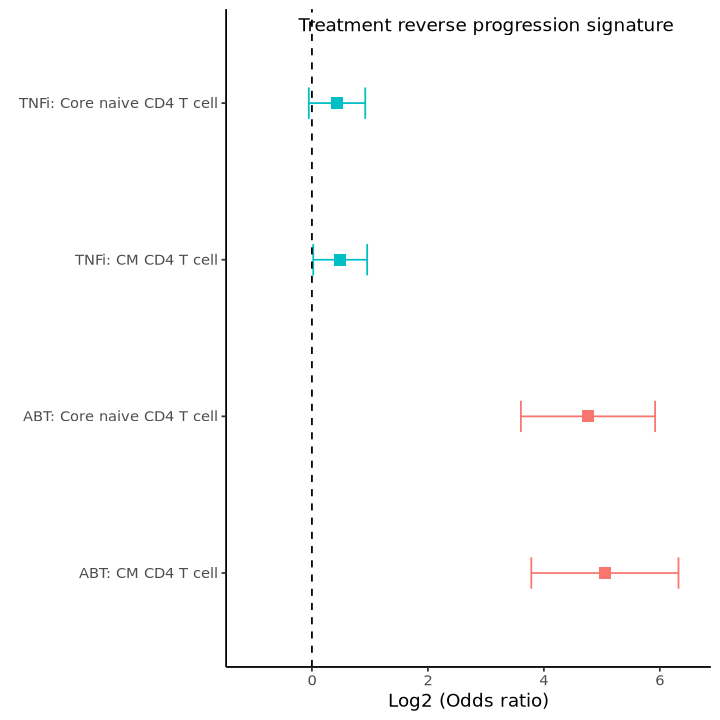

In [21]:
# plot the forest plot
p1 <- ggplot(or_results, aes(x = log2(Odds_Ratio), y = treament.celltype, color = treatment)) +
  geom_point(aes(x = log2(Odds_Ratio)), shape = 15, size = 3) +
  geom_errorbar(aes(xmin = log2(Lower_CI), xmax = log2(Upper_CI)), width = 0.2) +
  geom_vline(xintercept = 0, linetype = "dashed") +
  annotate("text", x = 3, y = 4.5, label = "Treatment reverse progression signature") +
  theme_classic() +
  xlab("Log2 (Odds ratio)") +
  guides(color = "none") +
  ylab("") +
  xlim(-1.1, 6.5)
p1
ggsave(file.path(fig_path, paste0(proj_name, "ABT_TNFi_odds_ratio_log2.pdf")),
  width = 4, height = 3
)

## run a z-test for the odds ratio

In [25]:
or_results

cell_type,treatment,Odds_Ratio,Lower_CI,Upper_CI,p_value,treament.celltype
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
CM CD4 T cell,ABT,33.179348,13.7629531,79.987857,0.00000000,ABT: CM CD4 T cell
CM CD4 T cell,TNFi,1.401962,1.0157347,1.935049,0.04037894,TNFi: CM CD4 T cell
Core naive CD4 T cell,ABT,27.107438,12.1551293,60.452931,0.00000000,ABT: Core naive CD4 T cell
Core naive CD4 T cell,TNFi,1.350000,0.9634894,1.891562,0.08212868,TNFi: Core naive CD4 T cell


In [26]:
#' Compare Odds Ratios Between Two Treatments Using a Z-Test
#'
#' Given a data frame with columns treatment, Odds_Ratio, Lower_CI, Upper_CI,
#' this function compares the odds ratios for "ABT" and "TNFi" using a z-test.
#'
#' @param df Data frame with columns: treatment, Odds_Ratio, Lower_CI, Upper_CI
#' @param alpha Significance level (default 0.05)
#' @return A list with z statistic and p-value, or NA if either treatment is missing
#' @examples
#' # df <- data.frame(treatment = c("ABT", "TNFi"), Odds_Ratio = c(2, 1.2), Lower_CI = c(1.5, 0.9), Upper_CI = c(2.7, 1.6))
#' # compare_ABT_TNFi(df)
compare_ABT_TNFi <- function(df, alpha = 0.05) {
  abt <- df %>% dplyr::filter(treatment == "ABT")
  tnfi <- df %>% dplyr::filter(treatment == "TNFi")
  log_or1 <- log(abt$Odds_Ratio[1])
  log_or2 <- log(tnfi$Odds_Ratio[1])
  se1 <- (log(abt$Upper_CI[1]) - log(abt$Lower_CI[1])) / (2 * qnorm(1 - alpha/2))
  se2 <- (log(tnfi$Upper_CI[1]) - log(tnfi$Lower_CI[1])) / (2 * qnorm(1 - alpha/2))
  z <- (log_or1 - log_or2) / sqrt(se1^2 + se2^2)
  p <- 2 * (1 - pnorm(abs(z)))
  return(list(z = z, p = p))
}

# Example usage:
# compare_ABT_TNFi(df)

In [27]:
compare_ABT_TNFi(or_results %>% filter(cell_type == "CM CD4 T cell"))
compare_ABT_TNFi(or_results %>% filter(cell_type == "Core naive CD4 T cell"))

$z
[1] 6.617678

$p
[1] 3.648859e-11

$z
[1] 6.75709

$p
[1] 1.407896e-11

In [28]:
sessionInfo()

R version 4.4.1 (2024-06-14)
Platform: x86_64-conda-linux-gnu
Running under: Ubuntu 22.04.5 LTS

Matrix products: default
BLAS/LAPACK: /home/workspace/environment/minimal/lib/libopenblasp-r0.3.28.so;  LAPACK version 3.12.0

locale:
 [1] LC_CTYPE=C.UTF-8    LC_NUMERIC=C        LC_TIME=C          
 [4] LC_COLLATE=C        LC_MONETARY=C       LC_MESSAGES=C      
 [7] LC_PAPER=C          LC_NAME=C           LC_ADDRESS=C       
[10] LC_TELEPHONE=C      LC_MEASUREMENT=C    LC_IDENTIFICATION=C

time zone: America/Los_Angeles
tzcode source: system (glibc)

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] epitools_0.5-10.1 broom_1.0.7       ggpubr_0.6.0      data.table_1.17.6
 [5] lubridate_1.9.4   forcats_1.0.0     stringr_1.5.1     dplyr_1.1.4      
 [9] purrr_1.0.4       readr_2.1.5       tidyr_1.3.1       tibble_3.2.1     
[13] ggplot2_3.5.2     tidyverse_2.0.0  

loaded via a namespace (and not attached):
 [1] 